In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# KHAI BÁO THƯ VIỆN
# ============================================================

import os
import yaml
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import Image, display
import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

os.environ['KAGGLE_CONFIG_DIR'] = "/content"
os.environ['KAGGLE_API_TOKEN'] = "KGAT_e697c72d5c330c320df3781c2a8bbc9e"

# Cài đặt thư viện
!pip install -q kaggle

# Tải dataset
!kaggle datasets download -d ngkhtrf/vietnamese-number-plate-detection-for-yolo

# Giải nén
!unzip -q -o vietnamese-number-plate-detection-for-yolo.zip -d /content/dataset_local

print("Tải dữ liệu thành công")

Dataset URL: https://www.kaggle.com/datasets/ngkhtrf/vietnamese-number-plate-detection-for-yolo
License(s): MIT
100% 959M/959M [00:10<00:00, 100MB/s] 

Tải dữ liệu thành công


In [ ]:
# ============================================================
# EDA
# ============================================================

# Đường dẫn tới thư mục dataset gốc
DATASET_PATH = "/content/dataset_local"

# Đọc file yaml
yaml_path = os.path.join(DATASET_PATH, "dataset.yaml")

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

def get_full_path(key):
    if key not in data_config: return None
    path = data_config[key].lstrip('/')
    return os.path.join(DATASET_PATH, path)

# Đường dẫn train/val/test
train_img_dir = get_full_path('train')
val_img_dir = get_full_path('val')
test_img_dir = get_full_path('test')

train_label_dir = train_img_dir.replace('images', 'labels') if train_img_dir else None
val_label_dir   = val_img_dir.replace('images', 'labels') if val_img_dir else None
test_label_dir  = test_img_dir.replace('images', 'labels') if test_img_dir else None

# Hàm đếm class
def count_classes(img_dir):
    label_dir = img_dir.replace('images', 'labels')
    counts = {}

    if not os.path.exists(label_dir):
        return counts

    for txt_file in os.listdir(label_dir):
        if txt_file.endswith('.txt'):
            with open(os.path.join(label_dir, txt_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts: continue

                    cls = int(parts[0])
                    counts[cls] = counts.get(cls, 0) + 1
    return counts

# Đếm số lượng ảnh
dirs = {'Train': train_img_dir, 'Val': val_img_dir, 'Test': test_img_dir}
img_counts = {k: len(os.listdir(v)) if v and os.path.exists(v) else 0 for k, v in dirs.items()}

# Đếm class
train_stats = count_classes(train_img_dir) if train_img_dir else {}
val_stats   = count_classes(val_img_dir) if val_img_dir else {}

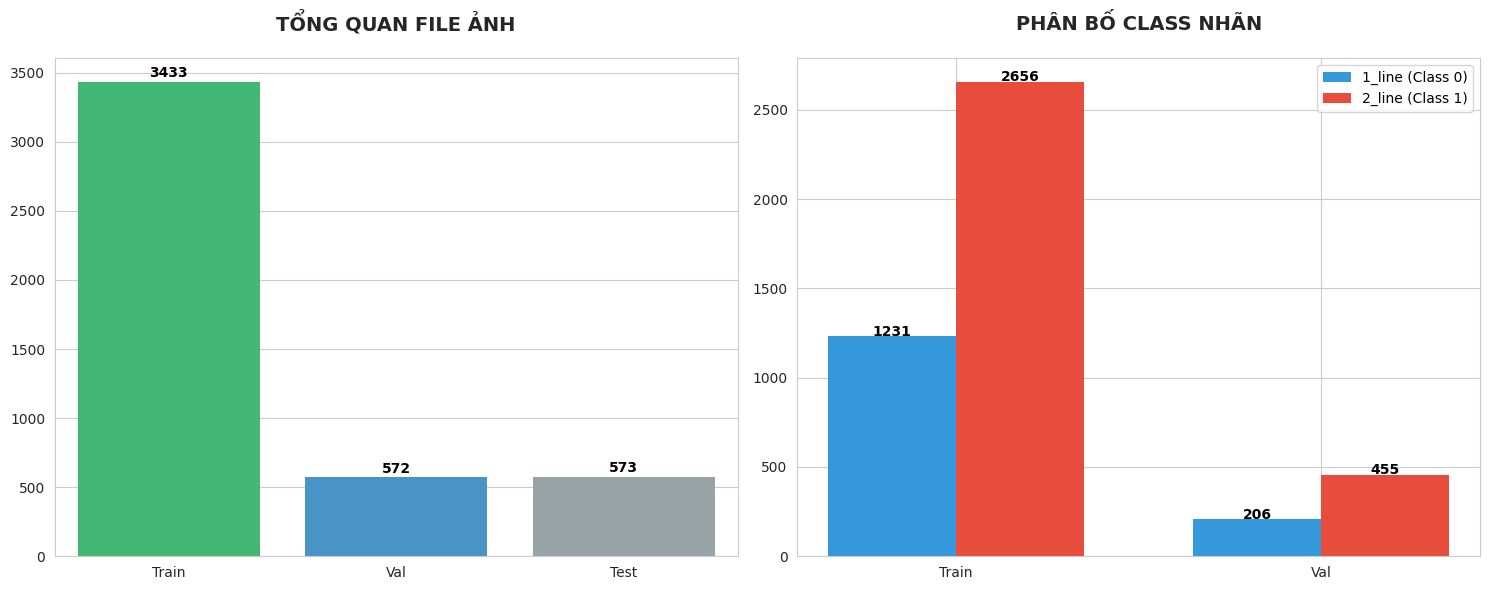

In [ ]:
with sns.axes_style("whitegrid"):
    plt.style.use('seaborn-v0_8-muted')
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Số lượng ảnh
colors_ds = ['#2ecc71', '#3498db', '#95a5a6']
sns.barplot(x=list(img_counts.keys()), y=list(img_counts.values()), ax=axes[0], palette=colors_ds, hue=list(img_counts.keys()), legend=False)
axes[0].set_title('TỔNG QUAN FILE ẢNH', fontsize=14, fontweight='bold', pad=20)
for i, v in enumerate(img_counts.values()):
    axes[0].text(i, v + (max(img_counts.values())*0.01), f'{v}', ha='center', fontweight='bold')

# Biểu đồ 2: Phân bố Class
labels = ['1_line (Class 0)', '2_line (Class 1)']
cls_0 = [train_stats.get(0, 0), val_stats.get(0, 0)]
cls_1 = [train_stats.get(1, 0), val_stats.get(1, 0)]

x = range(len(['Train', 'Val']))
width = 0.35

axes[1].bar([p - width/2 for p in x], cls_0, width, label=labels[0], color='#3498db') # Blue
axes[1].bar([p + width/2 for p in x], cls_1, width, label=labels[1], color='#e74c3c') # Red

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Val'])
axes[1].set_title('PHÂN BỐ CLASS NHÃN', fontsize=14, fontweight='bold', pad=20)
axes[1].legend()

for i in range(len(x)):
    axes[1].text(i - width/2, cls_0[i] + 5, str(cls_0[i]), ha='center', fontweight='bold')
    axes[1].text(i + width/2, cls_1[i] + 5, str(cls_1[i]), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

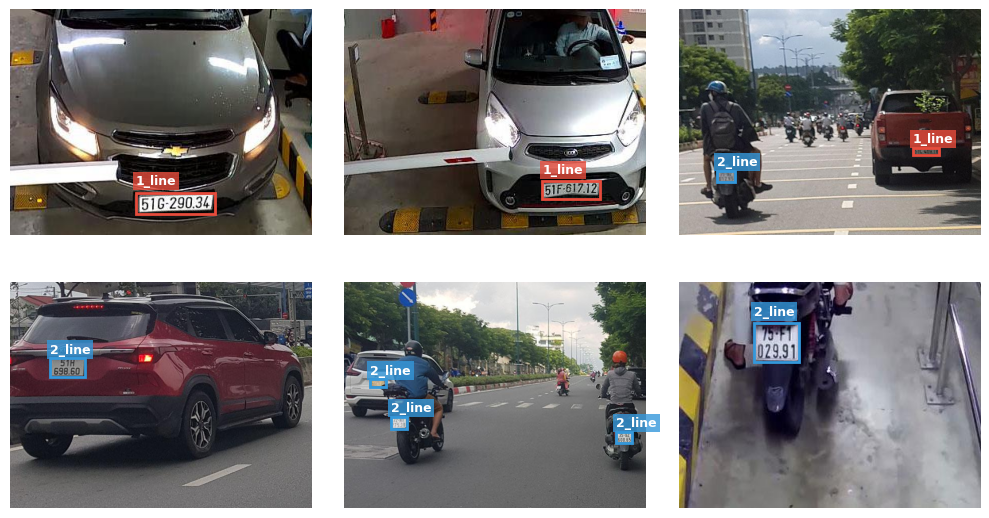

In [ ]:
# ============================================================
# TRỰC QUAN HÓA MẪU DỮ LIỆU
# ============================================================

def visualize_sample(img_dir, num_samples=6):
    label_dir = img_dir.replace('images', 'labels')

    img_paths = list(Path(img_dir).glob('*.[jp][pn]g'))
    samples = random.sample(img_paths, min(num_samples, len(img_paths)))

    fig, axs = plt.subplots(2, 3, figsize=(10, 6))
    axs = axs.flatten()
    class_map = {0: ('1_line', '#e74c3c'), 1: ('2_line', '#3498db')}

    for i, img_path in enumerate(samples):
        img = PILImage.open(img_path).convert('RGB')
        w, h = img.size
        ax = axs[i]
        ax.imshow(img)
        ax.axis('off')

        # Tìm file nhãn tương ứng
        label_path = Path(label_dir) / f"{img_path.stem}.txt"

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    cls_id, x, y, bw, bh = map(float, line.split())
                    name, color = class_map.get(int(cls_id), ('Unknown', '#2ecc71'))

                    # Tạo bounding box
                    rect = patches.Rectangle(
                        ((x - bw/2) * w, (y - bh/2) * h),
                        bw * w, bh * h,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text((x - bw/2) * w, (y - bh/2) * h - 10, name,
                            color='white', fontsize=9, fontweight='bold',
                            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))
    plt.tight_layout()
    plt.show()

visualize_sample(train_img_dir, num_samples=6)

In [ ]:
# ============================================================
# LÀM SẠCH DỮ LIỆU
# ============================================================

def clean_dataset(img_dir, label_dir, delete=False):
    bad_files = []
    img_dir = Path(img_dir)
    label_dir = Path(label_dir)

    # Lấy danh sách ảnh
    img_files = list(img_dir.glob('*.[jp][pn]g'))

    for img_path in tqdm.tqdm(img_files, desc=f"Cleaning {img_dir.name}"):
        label_path = label_dir / f"{img_path.stem}.txt"
        is_bad = False

        # Kiểm tra ảnh hỏng
        try:
            with PILImage.open(img_path) as img:
                img.verify()
        except:
            bad_files.append(str(img_path))
            is_bad = True

        # Kiểm tra nhãn
        if not is_bad:
            if not label_path.exists():
                continue

            try:
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    if not lines: # File trống
                        bad_files.append(str(label_path))
                        is_bad = True
                    else:
                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) != 5: # Không đủ 5 cột chuẩn YOLO
                                is_bad = True; break

                            # Kiểm tra tọa độ hợp lệ (0-1)
                            vals = list(map(float, parts))
                            if any(v < 0 or v > 1 for v in vals[1:]):
                                is_bad = True; break

                            # Loại bỏ box quá nhỏ (nhiễu < 0.1%)
                            if vals[3] * vals[4] < 0.001:
                                is_bad = True; break
            except:
                bad_files.append(str(label_path))
                is_bad = True

        # Xử lý xóa file nếu có lỗi
        if is_bad:
            bad_files.append(str(img_path)) # Đưa ảnh vào danh sách xóa luôn
            if delete:
                if img_path.exists(): os.remove(img_path)
                if label_path.exists(): os.remove(label_path)

    print(f"\n [Kết quả]: Tìm thấy {len(bad_files)} file lỗi/không hợp lệ.")
    return bad_files

bad_train = clean_dataset(train_img_dir, train_label_dir, delete=True)
bad_val = clean_dataset(val_img_dir, val_label_dir, delete=True)

Cleaning train: 100%|██████████| 3433/3433 [00:01<00:00, 2360.91it/s]



 [Kết quả]: Tìm thấy 19 file lỗi/không hợp lệ.


Cleaning val: 100%|██████████| 572/572 [00:00<00:00, 1001.95it/s]


 [Kết quả]: Tìm thấy 2 file lỗi/không hợp lệ.


In [ ]:
# Cập nhật đường dẫn
dataset_info = {
    'train': '/content/dataset_local/images/train',
    'val': '/content/dataset_local/images/val',
    'nc': 2,
    'names': ['1_line', '2_line']
}

yaml_path = '/content/dataset_local/dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_info, f, default_flow_style=False)

print("Đã cập nhật lại file yaml!")
!cat {yaml_path}

Đã cập nhật lại file yaml!
names:
- 1_line
- 2_line
nc: 2
train: /content/dataset_local/images/train
val: /content/dataset_local/images/val


In [ ]:
# ============================================================
# HUẤN LUYỆN YOLO26
# ============================================================

save_dir = '/content/drive/MyDrive/YOLO26'

# Load model
model = YOLO("yolo26n.pt")

# Huấn luyện
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=32,
    patience=15,
    project=save_dir,
    name="train",
    exist_ok=True,
    device=0,
    optimizer='auto',
)

print("Huấn luyện hoàn tất!")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_local/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

In [ ]:
# Gọi file last.pt từ vị trí bị sập để chạy nốt
model = YOLO('/content/drive/MyDrive/YOLO26/train/weights/last.pt')
model.train(resume=True)


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_local/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/YOLO26/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7898de337e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

=== BIỂU ĐỒ LOSS & ĐỘ CHÍNH XÁC ===


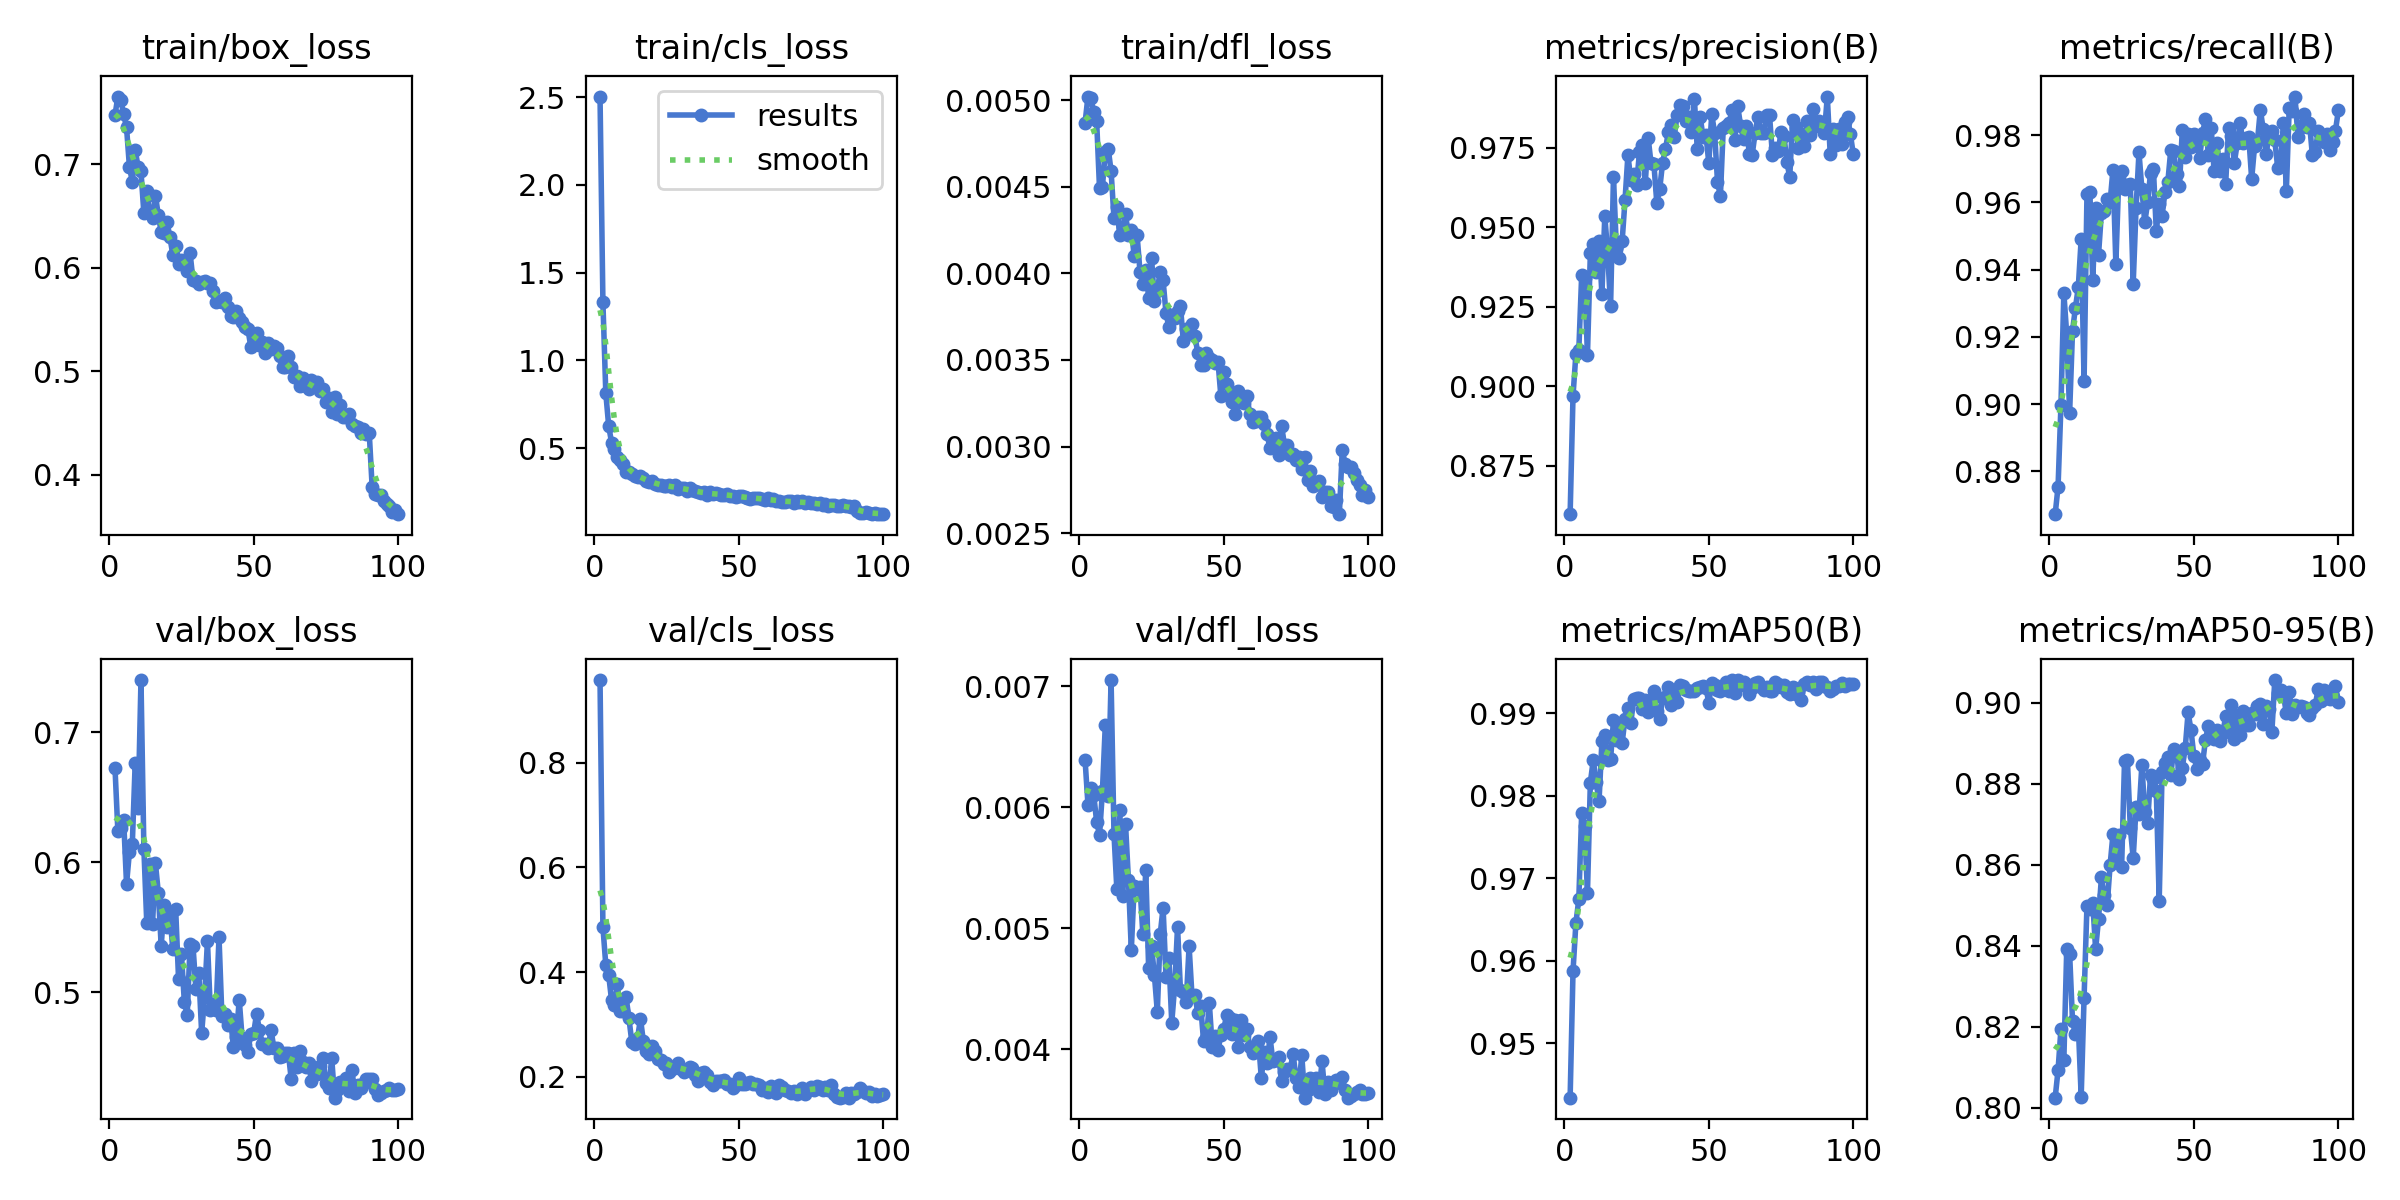

In [ ]:
# Xác định đường dẫn file ảnh kết quả trên Google Drive
loss_img_path = os.path.join('/content/drive/MyDrive/YOLO26/train', 'results.png')

# Hiển thị biểu đồ loss
if os.path.exists(loss_img_path):
    img = PILImage.open(loss_img_path)
    print("=== BIỂU ĐỒ LOSS & ĐỘ CHÍNH XÁC ===")
    display(img)
else:
    print("Không tìm thấy file results.png trên Drive")


=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===


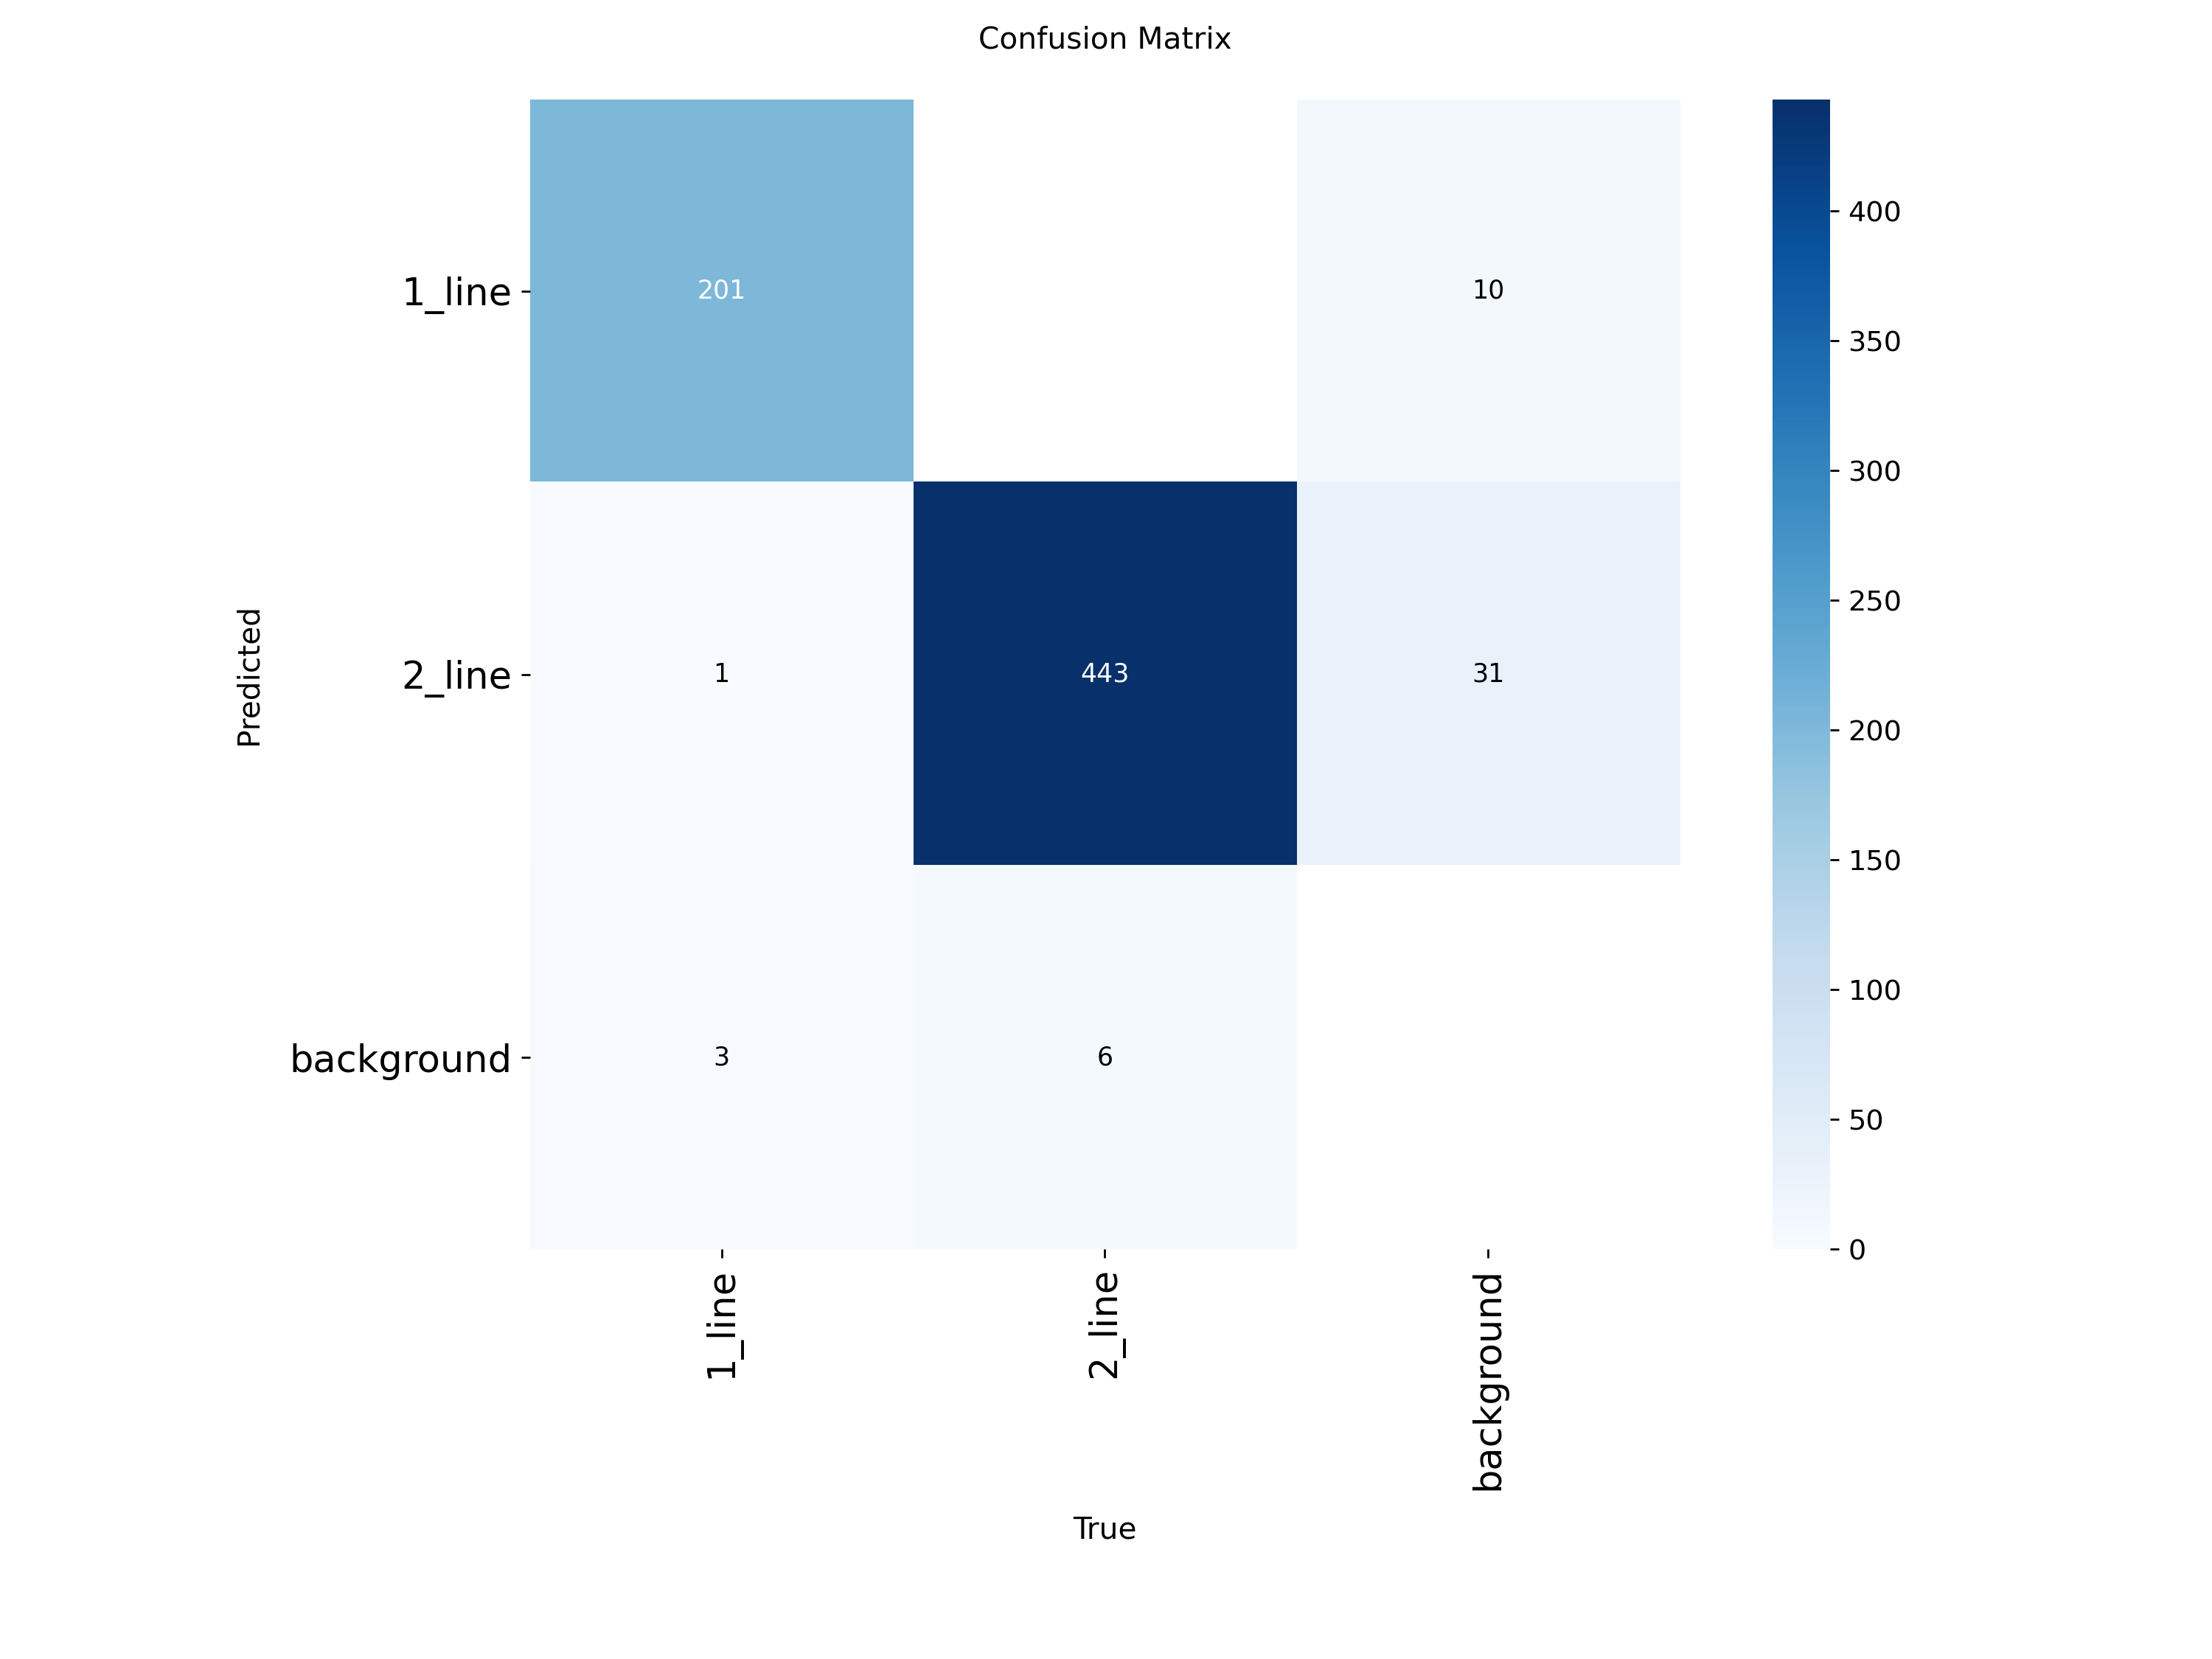

In [ ]:
# Xác định đường dẫn file ma trận nhầm lẫn
cm_img_path = os.path.join('/content/drive/MyDrive/YOLO26/train', 'confusion_matrix.png')

# Hiển thị ma trận nhầm lẫn
if os.path.exists(cm_img_path):
    img = PILImage.open(cm_img_path)
    print("=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===")
    display(img)
else:
    print("Không tìm thấy file confusion_matrix.png trên Drive")
